# Dataset-Level Attribution Analysis (U-ED-LSTM BPIC17)

This notebook computes and analyzes attribution patterns across the full dataset:

1. **Average feature attribution** for Activity, Resource, and temporal features
2. **Attribution by categorical value** for top-5 most common activities and resources
3. **Test mode** for quick validation with a subset

**Note**: Full dataset computation can take significant time. Use test mode first.

## 1. Setup

In [1]:
# Path setup and config import
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

# Add both project root and src/ to path (src/ needed for pickle compatibility)
if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))
if str(_current / 'src') not in sys.path:
    sys.path.insert(0, str(_current / 'src'))

from src.interpretability.config.bpic17_config import CONFIG
print(f"Dataset: {CONFIG.dataset_name}")

Dataset: BPIC17


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from collections import defaultdict
import pickle
import random

from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability import InterpretabilityTool

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Reproducibility
SEED = CONFIG.seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
# Load model and data
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')
model = model.to(device)

test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)

eval_helper = Evaluation(
    model=model,
    dataset=test_dataset,
    concept_name=CONFIG.concept_name,
    growing_num_values=CONFIG.growing_num_values,
    all_cat=CONFIG.all_cat,
    all_num=CONFIG.all_num
)

tool = InterpretabilityTool(model, model.data_set_categories, device=device)

print(f"Loaded {len(test_dataset)} samples")
print(f"Available cases: {len(eval_helper.cases)}")

Data set categories:  ([('concept:name', 28, {'A_Accepted': 1, 'A_Cancelled': 2, 'A_Complete': 3, 'A_Concept': 4, 'A_Create Application': 5, 'A_Denied': 6, 'A_Incomplete': 7, 'A_Pending': 8, 'A_Submitted': 9, 'A_Validating': 10, 'EOS': 11, 'O_Accepted': 12, 'O_Cancelled': 13, 'O_Create Offer': 14, 'O_Created': 15, 'O_Refused': 16, 'O_Returned': 17, 'O_Sent (mail and online)': 18, 'O_Sent (online only)': 19, 'W_Assess potential fraud': 20, 'W_Call after offers': 21, 'W_Call incomplete files': 22, 'W_Complete application': 23, 'W_Handle leads': 24, 'W_Personal Loan collection': 25, 'W_Shortened completion ': 26, 'W_Validate application': 27}), ('Action', 7, {'Created': 1, 'Deleted': 2, 'EOS': 3, 'Obtained': 4, 'Released': 5, 'statechange': 6}), ('org:resource', 151, {'EOS': 1, 'User_1': 2, 'User_10': 3, 'User_100': 4, 'User_101': 5, 'User_102': 6, 'User_103': 7, 'User_104': 8, 'User_105': 9, 'User_106': 10, 'User_107': 11, 'User_108': 12, 'User_109': 13, 'User_11': 14, 'User_110': 15, 'U

Loaded 253196 samples
Available cases: 6301


## 2. Configuration

In [4]:
# ============================================================
# CONFIGURATION
# ============================================================
TEST_MODE = True          # Set to False for full dataset analysis
CONFIG.use_improved = False  # set True for the improved variant
TEST_SAMPLE_SIZE = 200     # Number of samples in test mode
IG_STEPS = 30             # Integration steps (reduce for speed)
TARGET = CONFIG.concept_name  # Attribution target

# Get ALL input features from the model (not a subset)
# This ensures attribution is always computed w.r.t. all input features
cat_categories, num_categories = model.data_set_categories
ALL_CAT_FEATURES = [name for name, _, _ in cat_categories]
ALL_NUM_FEATURES = [name for name, _, _ in num_categories]
ALL_FEATURES = ALL_CAT_FEATURES + ALL_NUM_FEATURES

print(f"Mode: {'TEST' if TEST_MODE else 'FULL'}")
print(f"All input features ({len(ALL_FEATURES)} total):")
print(f"  Categorical: {ALL_CAT_FEATURES}")
print(f"  Numerical: {ALL_NUM_FEATURES}")

Mode: TEST
All input features (18 total):
  Categorical: ['concept:name', 'Action', 'org:resource', 'EventOrigin', 'lifecycle:transition', 'case:LoanGoal', 'case:ApplicationType', 'Accepted', 'Selected']
  Numerical: ['case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day', 'case:RequestedAmount', 'FirstWithdrawalAmount', 'NumberOfTerms', 'MonthlyCost', 'CreditScore']


## 3. Prepare Samples

In [5]:
# Collect all prefix-suffix pairs
all_samples = []

for case_name, full_case in tqdm(eval_helper.cases.items(), desc="Collecting samples"):
    for prefix_len, prefix, suffix in eval_helper._iterate_case(full_case):
        if prefix_len >= 1:  # At least 1 event
            all_samples.append({
                'case_name': case_name,
                'prefix_len': prefix_len,
                'prefix': prefix,
                'suffix': suffix
            })

print(f"Total samples: {len(all_samples)}")

# Sample if in test mode
if TEST_MODE:
    samples = random.sample(all_samples, min(TEST_SAMPLE_SIZE, len(all_samples)))
    print(f"Using {len(samples)} samples (test mode)")
else:
    samples = all_samples
    print(f"Using all {len(samples)} samples (full mode)")

Total samples: 233080
Using 200 samples (test mode)


## 4. Compute Attributions

In [6]:
# Compute attributions for all samples
attribution_results = []

for sample in tqdm(samples, desc="Computing attributions"):
    try:
        prefix = sample['prefix']
        prefix_len = sample['prefix_len']
        
        # Convert prefix
        cat_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[0]]
        num_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[1]]
        process = (cat_tensors, num_tensors)
        
        # Compute attribution
        attr_map = tool.compute_attribution_map(
            process=process,
            prefix_length=prefix_len,
            target=TARGET,
            target_class='auto',
            method='integrated_gradients',
            n_steps=IG_STEPS
        )
        
        # Extract feature attributions
        feature_attrs = {}
        for feat in attr_map.feature_names:
            if feat in attr_map.attributions:
                vals = attr_map.attributions[feat]
                if hasattr(vals, 'detach'):
                    vals = vals.detach().cpu().numpy()
                feature_attrs[feat] = np.abs(vals).sum()
        
        # Get predicted activity
        pred_activity = attr_map.target_description.split('=')[1].split('(')[0].strip() if '=' in attr_map.target_description else 'Unknown'
        
        attribution_results.append({
            'case_name': sample['case_name'],
            'prefix_len': prefix_len,
            'predicted_activity': pred_activity,
            **feature_attrs
        })
        
    except Exception as e:
        print(f"Error for {sample['case_name']}: {e}")

results_df = pd.DataFrame(attribution_results)
print(f"\nComputed attributions for {len(results_df)} samples")

Computing attributions:   0%|          | 0/200 [00:00<?, ?it/s]


Computed attributions for 200 samples


## 5. Average Feature Attribution (4 Views)

In [7]:
# Compute average attribution per feature
available_features = [f for f in ALL_FEATURES if f in results_df.columns]

avg_attribution = results_df[available_features].mean()
std_attribution = results_df[available_features].std()

print("Average Feature Attribution:")
print("="*60)
for feat in available_features:
    print(f"{feat:25s}: {avg_attribution[feat]:.6f} ± {std_attribution[feat]:.6f}")

Average Feature Attribution:
concept:name             : 2.439194 ± 0.733304
Action                   : 0.306371 ± 0.144173
org:resource             : 0.620060 ± 0.200636
EventOrigin              : 0.437816 ± 0.265207
lifecycle:transition     : 1.327345 ± 0.784561
case:LoanGoal            : 0.126183 ± 0.064316
case:ApplicationType     : 0.051782 ± 0.021256
Accepted                 : 0.232692 ± 0.100419
Selected                 : 0.206549 ± 0.092800
case_elapsed_time        : 0.438038 ± 0.424000
event_elapsed_time       : 0.241582 ± 0.192523
day_in_week              : 0.021637 ± 0.017564
seconds_in_day           : 0.020592 ± 0.017488
case:RequestedAmount     : 0.033944 ± 0.034210
FirstWithdrawalAmount    : 0.002865 ± 0.005661
NumberOfTerms            : 0.004040 ± 0.006087
MonthlyCost              : 0.002525 ± 0.006710
CreditScore              : 0.022817 ± 0.032857


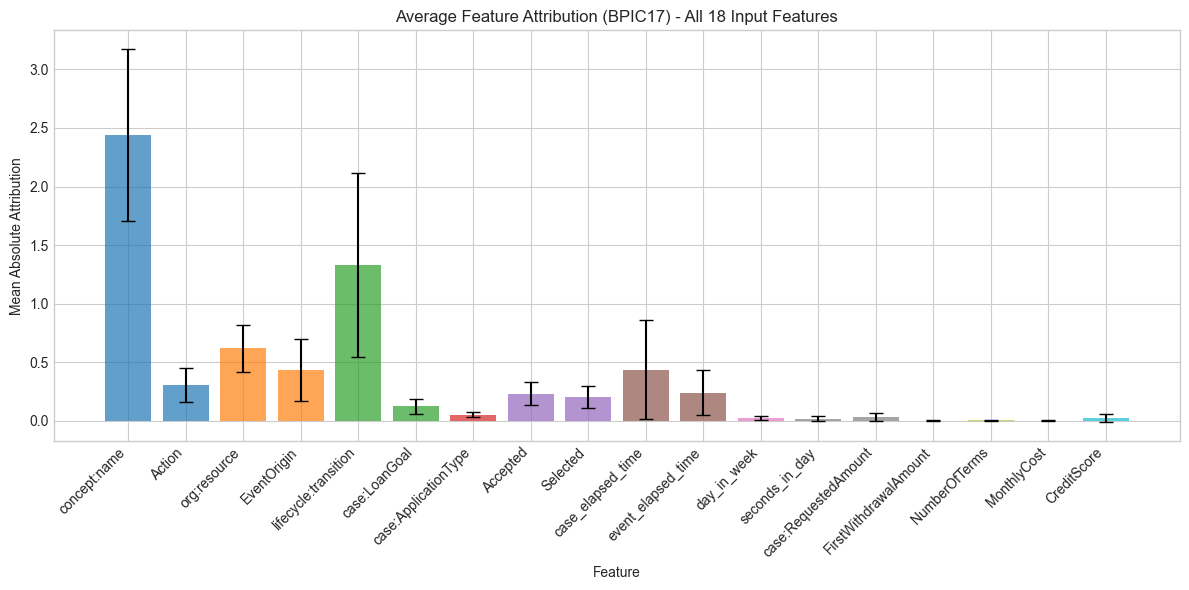

In [8]:
# View 1: Bar chart of average attribution
fig, ax = plt.subplots(figsize=(12, 6))

# Use a colormap that scales with number of features
colors = plt.cm.tab10(np.linspace(0, 1, len(available_features)))
bars = ax.bar(available_features, avg_attribution[available_features], 
              yerr=std_attribution[available_features], capsize=5, 
              color=colors, alpha=0.7)

ax.set_ylabel('Mean Absolute Attribution')
ax.set_xlabel('Feature')
ax.set_title(f'Average Feature Attribution ({CONFIG.dataset_name}) - All {len(available_features)} Input Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

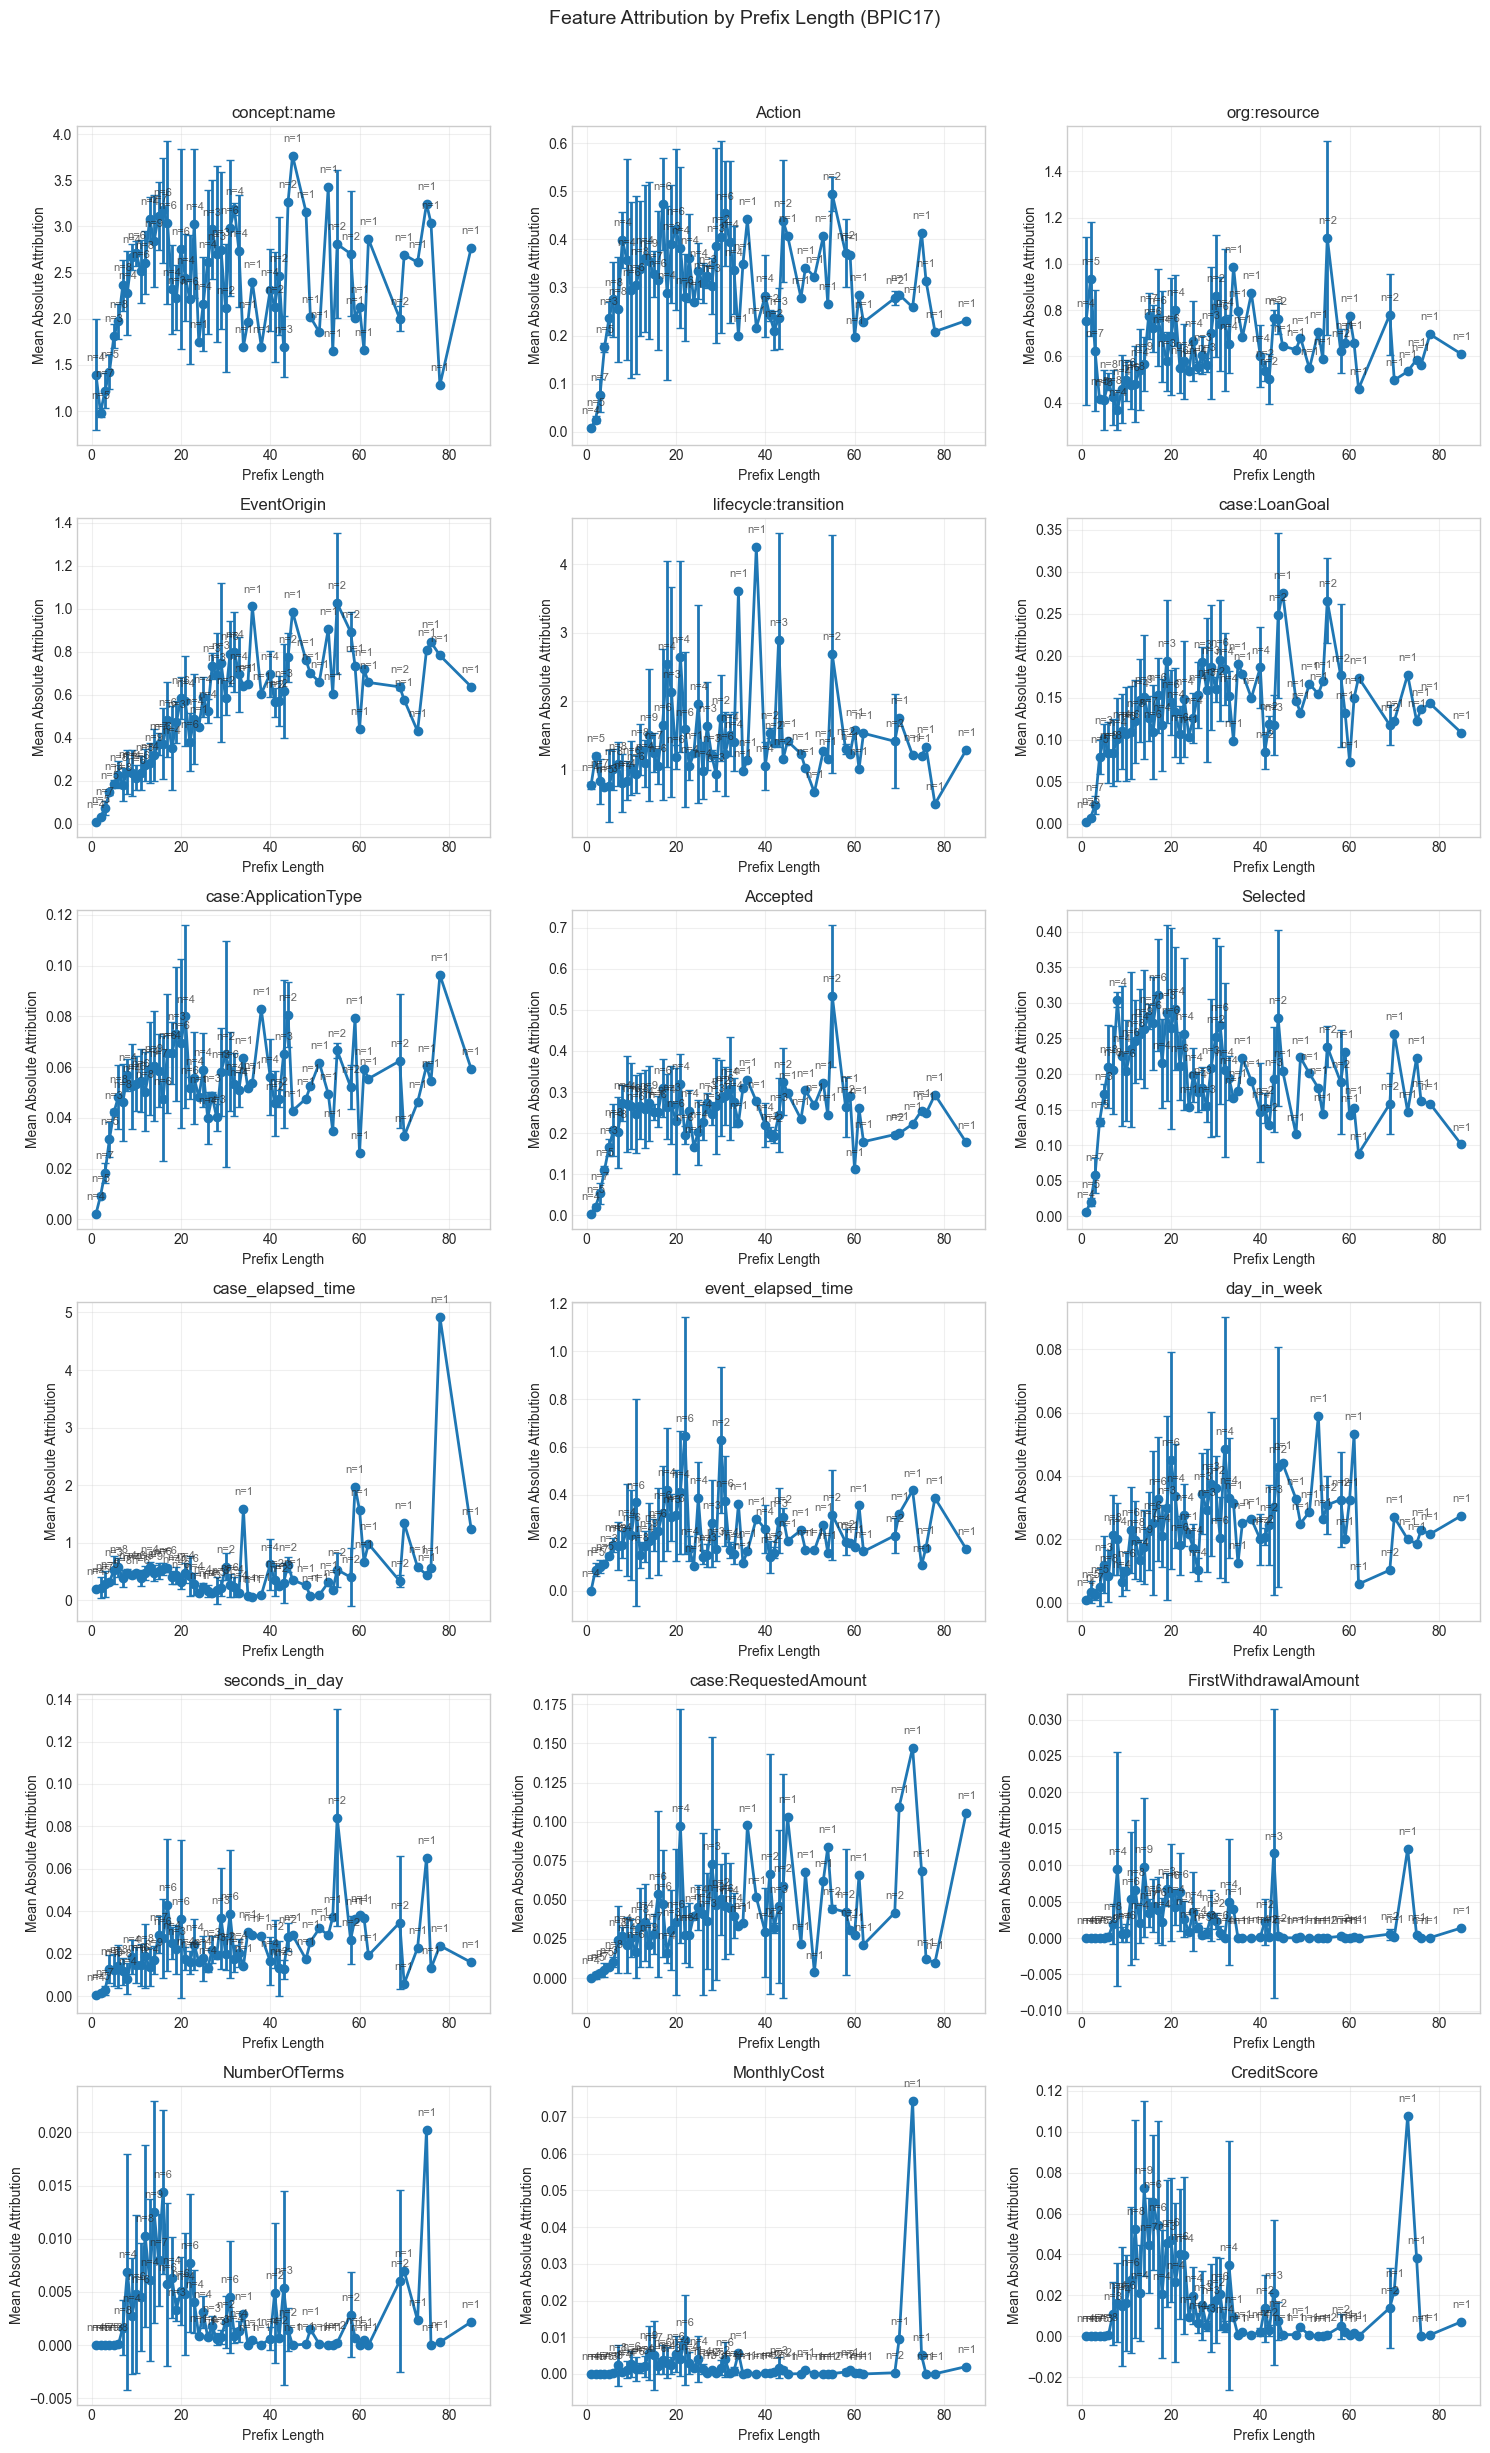


Sample distribution by prefix length:
  Prefix 1: n=4
  Prefix 2: n=5
  Prefix 3: n=7
  Prefix 4: n=5
  Prefix 5: n=3
  Prefix 6: n=8
  Prefix 7: n=8
  Prefix 8: n=4
  Prefix 9: n=4
  Prefix 10: n=6
  Prefix 11: n=6
  Prefix 12: n=8
  Prefix 13: n=4
  Prefix 14: n=9
  Prefix 15: n=7
  Prefix 16: n=6
  Prefix 17: n=6
  Prefix 18: n=4
  Prefix 19: n=3
  Prefix 20: n=6
  Prefix 21: n=4
  Prefix 22: n=6
  Prefix 23: n=4
  Prefix 24: n=1
  Prefix 25: n=4
  Prefix 26: n=4
  Prefix 27: n=3
  Prefix 28: n=3
  Prefix 29: n=3
  Prefix 30: n=2
  Prefix 31: n=6
  Prefix 32: n=4
  Prefix 33: n=4
  Prefix 34: n=1
  Prefix 35: n=1
  Prefix 36: n=1
  Prefix 38: n=1
  Prefix 40: n=4
  Prefix 41: n=2
  Prefix 42: n=2
  Prefix 43: n=3
  Prefix 44: n=2
  Prefix 45: n=1
  Prefix 48: n=1
  Prefix 49: n=1
  Prefix 51: n=1
  Prefix 53: n=1
  Prefix 54: n=1
  Prefix 55: n=2
  Prefix 58: n=2
  Prefix 59: n=1
  Prefix 60: n=1
  Prefix 61: n=1
  Prefix 62: n=1
  Prefix 69: n=2
  Prefix 70: n=1
  Prefix 73: n=1
 

In [9]:
# View 3: Attribution by prefix length
n_features = len(available_features)
n_cols = min(3, n_features)
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
if n_features == 1:
    axes = [axes]
else:
    axes = axes.flatten() if n_features > 1 else [axes]

# Get sample counts per prefix length
prefix_counts = results_df.groupby('prefix_len').size()

for idx, feat in enumerate(available_features):
    ax = axes[idx]
    
    # Group by prefix length
    grouped = results_df.groupby('prefix_len')[feat].agg(['mean', 'std'])
    
    ax.errorbar(grouped.index, grouped['mean'], yerr=grouped['std'], 
                marker='o', capsize=3, linewidth=2, markersize=6)
    ax.set_xlabel('Prefix Length')
    ax.set_ylabel('Mean Absolute Attribution')
    ax.set_title(f'{feat}')
    ax.grid(True, alpha=0.3)
    
    # Add sample count annotations
    for pl in grouped.index:
        n = prefix_counts[pl]
        ax.annotate(f'n={n}', (pl, grouped.loc[pl, 'mean']), 
                    textcoords="offset points", xytext=(0, 10), 
                    ha='center', fontsize=8, alpha=0.7)

# Hide unused subplots
for idx in range(n_features, len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Feature Attribution by Prefix Length ({CONFIG.dataset_name})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print sample distribution
print("\nSample distribution by prefix length:")
for pl in sorted(prefix_counts.index):
    print(f"  Prefix {pl}: n={prefix_counts[pl]}")

## 6. Attribution by Categorical Value (10 Views)

In [10]:
# Find top-5 most common predicted activities
activity_counts = results_df['predicted_activity'].value_counts()
top_activities = activity_counts.head(5).index.tolist()

print(f"Top 5 predicted activities:")
for act in top_activities:
    print(f"  {act}: {activity_counts[act]} predictions")

Top 5 predicted activities:
  W_Complete application: 43 predictions
  W_Validate application: 40 predictions
  W_Call after offers: 40 predictions
  W_Call incomplete files: 32 predictions
  A_Validating: 8 predictions


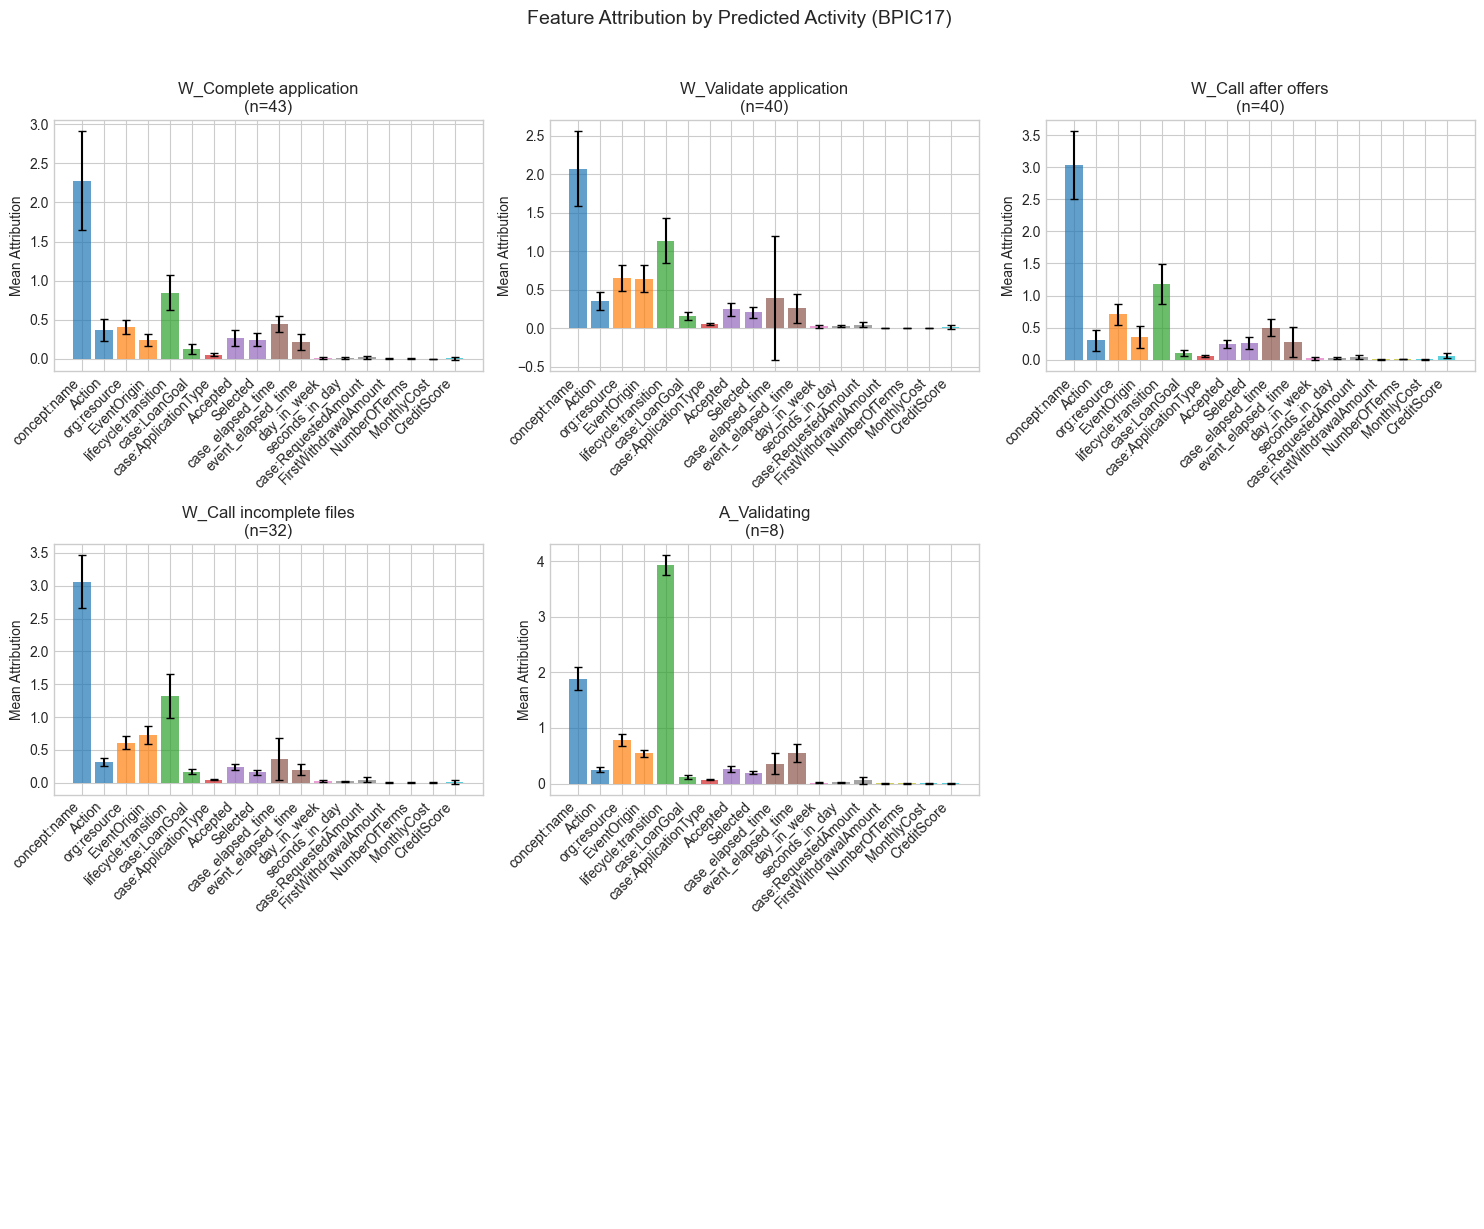

In [11]:
# Views 1-5: Attribution for each of top-5 activities
n_activities = min(5, len(top_activities))
n_cols = min(3, n_activities)
n_rows = (n_activities + n_cols - 1) // n_cols + (1 if n_activities % n_cols != 0 else 0)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten() if n_activities > 1 else [axes]

# Use colormap for dynamic number of features
colors = plt.cm.tab10(np.linspace(0, 1, len(available_features)))

for idx, activity in enumerate(top_activities[:n_activities]):
    ax = axes[idx]
    
    # Filter to this activity
    activity_df = results_df[results_df['predicted_activity'] == activity]
    
    if len(activity_df) > 0:
        means = activity_df[available_features].mean()
        stds = activity_df[available_features].std()
        
        ax.bar(range(len(available_features)), means, yerr=stds, capsize=3,
               color=colors, alpha=0.7)
        ax.set_xticks(range(len(available_features)))
        ax.set_xticklabels(available_features, rotation=45, ha='right')
        ax.set_ylabel('Mean Attribution')
        ax.set_title(f'{activity}\n(n={len(activity_df)})')

# Hide unused subplots
for idx in range(n_activities, len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Feature Attribution by Predicted Activity ({CONFIG.dataset_name})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# Summary table: Attribution by activity
activity_summary = []

for activity in top_activities:
    activity_df = results_df[results_df['predicted_activity'] == activity]
    
    row = {'Activity': activity, 'Count': len(activity_df)}
    for feat in available_features:
        row[f'{feat}_mean'] = activity_df[feat].mean()
    activity_summary.append(row)

summary_df = pd.DataFrame(activity_summary)
print("\nAttribution Summary by Predicted Activity:")
display(summary_df)


Attribution Summary by Predicted Activity:


,Activity,Count,concept:name_mean,Action_mean,org:resource_mean,EventOrigin_mean,lifecycle:transition_mean,case:LoanGoal_mean,case:ApplicationType_mean,Accepted_mean,Selected_mean,case_elapsed_time_mean,event_elapsed_time_mean,day_in_week_mean,seconds_in_day_mean,case:RequestedAmount_mean,FirstWithdrawalAmount_mean,NumberOfTerms_mean,MonthlyCost_mean,CreditScore_mean
0,W_Complete application,43,2.276508,0.369264,0.405516,0.241480,0.848234,0.126897,0.054310,0.264063,0.245332,0.447065,0.213972,0.015308,0.015075,0.018698,0.003096,0.001929,0.000487,0.007850
1,W_Validate application,40,2.072506,0.349687,0.648860,0.641814,1.134094,0.158444,0.055313,0.243658,0.206450,0.392771,0.257442,0.026136,0.025877,0.046203,0.002257,0.002345,0.002456,0.016412
2,W_Call after offers,40,3.033614,0.303488,0.709755,0.355186,1.175778,0.107495,0.058270,0.243662,0.258210,0.500362,0.275809,0.024745,0.025438,0.037998,0.004165,0.011175,0.004746,0.065663
3,W_Call incomplete files,32,3.062200,0.313617,0.610197,0.728493,1.316341,0.167728,0.048709,0.244649,0.157305,0.366976,0.197860,0.029326,0.020814,0.046908,0.001477,0.001871,0.003030,0.013991
4,A_Validating,8,1.885384,0.249892,0.787548,0.542995,3.926996,0.115293,0.068812,0.265257,0.197713,0.355797,0.551742,0.017241,0.023161,0.057025,0.006219,0.002712,0.003179,0.004741


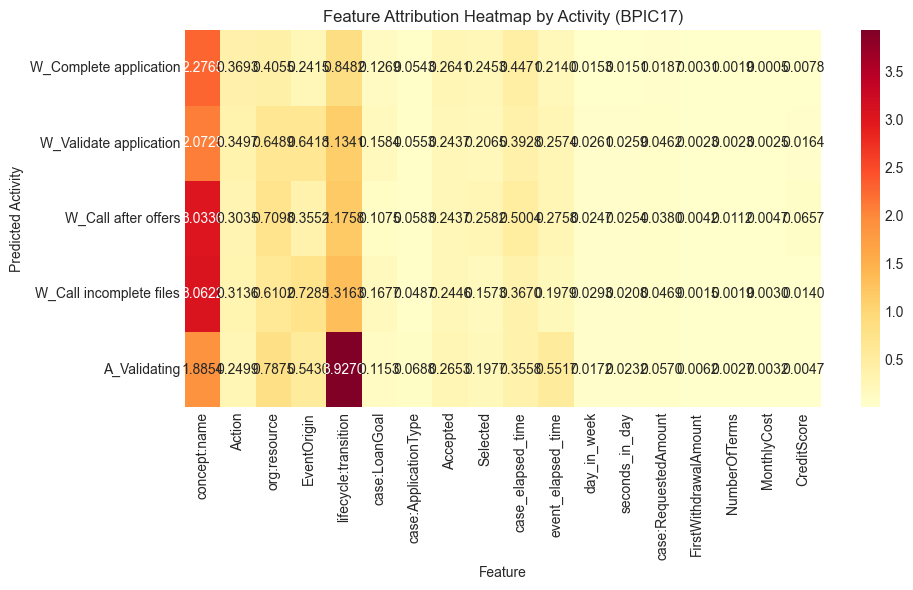

In [13]:
# Views 6-10: Heatmap of feature attribution by activity
# Create pivot table
heatmap_data = summary_df.set_index('Activity')[[f'{f}_mean' for f in available_features]]
heatmap_data.columns = available_features

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap='YlOrRd', fmt='.4f', ax=ax)
ax.set_title(f'Feature Attribution Heatmap by Activity ({CONFIG.dataset_name})')
ax.set_ylabel('Predicted Activity')
ax.set_xlabel('Feature')
plt.tight_layout()
plt.show()

## 7. Save Results

In [14]:
# Save results
output_dir = CONFIG.get_results_dir()

mode_suffix = '_test' if TEST_MODE else '_full'
output_path = output_dir / f'dataset_attribution_results{mode_suffix}.pkl'

with open(output_path, 'wb') as f:
    pickle.dump({
        'results_df': results_df,
        'avg_attribution': avg_attribution.to_dict(),
        'activity_summary': summary_df,
        'config': CONFIG.to_dict(),
        'test_mode': TEST_MODE
    }, f)

print(f"Results saved to: {output_path}")

Results saved to: /Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/src/interpretability/notebooks/results/bpic17/dataset_attribution_results_test.pkl


## 8. Summary

In [15]:
print("="*80)
print(f"SUMMARY: Dataset-Level Attribution Analysis")
print("="*80)
print(f"\nDataset: {CONFIG.dataset_name}")
print(f"Mode: {'TEST' if TEST_MODE else 'FULL'}")
print(f"Samples analyzed: {len(results_df)}")
print(f"Total input features: {len(available_features)}")

print(f"\n--- Average Feature Attribution (All {len(available_features)} Features) ---")
# Sort by attribution value
sorted_attrs = avg_attribution[available_features].sort_values(ascending=False)
for feat in sorted_attrs.index:
    print(f"{feat:25s}: {sorted_attrs[feat]:.6f}")

print(f"\n--- Top Predicted Activities ---")
for act in top_activities[:5]:
    print(f"{act}: {activity_counts[act]} predictions")

SUMMARY: Dataset-Level Attribution Analysis

Dataset: BPIC17
Mode: TEST
Samples analyzed: 200
Total input features: 18

--- Average Feature Attribution (All 18 Features) ---
concept:name             : 2.439194
lifecycle:transition     : 1.327345
org:resource             : 0.620060
case_elapsed_time        : 0.438038
EventOrigin              : 0.437816
Action                   : 0.306371
event_elapsed_time       : 0.241582
Accepted                 : 0.232692
Selected                 : 0.206549
case:LoanGoal            : 0.126183
case:ApplicationType     : 0.051782
case:RequestedAmount     : 0.033944
CreditScore              : 0.022817
day_in_week              : 0.021637
seconds_in_day           : 0.020592
NumberOfTerms            : 0.004040
FirstWithdrawalAmount    : 0.002865
MonthlyCost              : 0.002525

--- Top Predicted Activities ---
W_Complete application: 43 predictions
W_Validate application: 40 predictions
W_Call after offers: 40 predictions
W_Call incomplete files: 32 pr